In [3]:
import pandas as pd
# divide los datos
from sklearn.model_selection import train_test_split

# cargar dataset original
df_partidos = pd.read_csv('../datos/partidos_cebollitas_fe82a1a4-e109-41b1-8b78-d9b4341dacaf.csv')

df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

# variables predictorias
x = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y= df_partidos['diferencia_goles']

# division estandar 80% entrenamiento / 20% prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.linear_model import LinearRegression

# instanciar y entregar modelo
modelo_rl = LinearRegression()
modelo_rl.fit(x_train, y_train)

print('Modelo entrenado exitosamente')

Modelo entrenado exitosamente


In [ ]:
# mostrar coeficientes-> modelo rl intercepto = beta0
print(f'Intercepto β൦: {modelo_rl.intercept_}')
# contiene los arrglos de los coeficientes
print(f'Coeficiente β൦: {modelo_rl.coef_}')

# interceptacion amigable
for idx, col_name in enumerate(x.columns):
    print(f'Si aumentamos 1 unidad en {col_name}, la diferencia de goles cambia en promedio {modelo_rl.coef_[idx]:.2f}')

Intercepto β൦: -2.5257192572329763
Coeficiente β൦: [ 0.05596278 -0.05125811]
Si aumentamos 1 unidad en posesion_local (%), la diferencia de goles cambia en promedio 0.06
Si aumentamos 1 unidad en tiros_arco_local, la diferencia de goles cambia en promedio -0.05


In [6]:
# hacer predicciones (usa la linea ajustada para calcular)
y_pred = modelo_rl.predict(x_test)

# comparar predicciones vs valores reales
df_resultados = x_test.copy()
df_resultados['Diferencia_Goles_Real'] = y_test
df_resultados['Diferencia_Goles_Pedicha'] = y_pred.round(2)

df_resultados.head(10)

,posesion_local (%),tiros_arco_local,Diferencia_Goles_Real,Diferencia_Goles_Pedicha
83,47,3,3,-0.05
53,60,3,3,0.68
70,50,5,0,0.02
45,57,7,3,0.31
44,45,5,5,-0.26
39,60,7,3,0.47
22,45,11,0,-0.57
80,49,5,1,-0.04
10,48,5,-2,-0.10
0,54,12,2,-0.12


<function matplotlib.pyplot.show(close=None, block=None)>

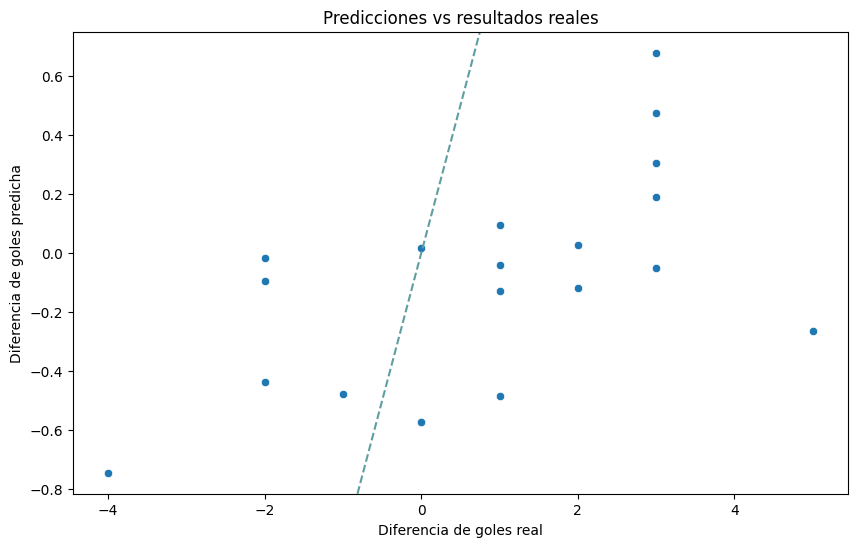

In [9]:
import matplotlib.pyplot as plt 
import seaborn as sns

# crear grafico de dispersion
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Diferencia de goles real')
plt.ylabel('Diferencia de goles predicha')
plt.title('Predicciones vs resultados reales')
plt.axline((0,0), slope=1, color='cadetblue', linestyle='--' )
plt.show


In [ ]:
import ipywidgets as widgets

# widgets de entrada 
posesion_input = widgets.FloatSlider(min=30, max=70, step=1, description='Posesion (%)')
tiros_input = widgets.IntSlider(min=1, max=15, step=1, description='Tiros al arco')

# funcion de prediccion
def prediccion_goles(posesion, tiros):
    # crear dataframe con nombres de columnas esperadas en el modelo
    entrada = pd.DataFrame([[posesion, tiros]], columns=['posesion_local (%)', 'tiros_arco_local'])
    pred = modelo_rl.predict(entrada)[0]
    print(f'Diferencia de goles predicha: {pred:.2f}')

# # mostrar widget interativos
widgets.interactive(prediccion_goles, posesion=posesion_input, tiros=tiros_input)

interactive(children=(FloatSlider(value=30.0, description='Posesion (%)', max=70.0, min=30.0, step=1.0), IntSl…